## Setup

Make sure that you install the requirements into a venv and enable that kernel before running this notebook.

In [1]:
import json
import pandas as pd
import numpy as np

from collections import Counter

## Data Ingestion

In [2]:
def format_raw_json():
    """Extract complete structure of stringified JSON files.
    
    Parses agentic policy records to view different metrics.
    
    Args:
        None
    
    Returns:
        pd.DataFrame: Returns complete DataFrame or one that is empty.
    """
    rows = []
    with open('./interactive_agent.jsonl', 'r') as agent_file:
        counter = 0
        for line in agent_file:
            # line comes in as a raw string, need loads()
            line = json.loads(line)

            # initialize Counters for roles and tool calls
            tool_counts = Counter()
            role_counts = Counter()

            # initialize containers for not blocking the DataFrame generation
            total_tool_calls = 0
            system_prompt = ""
            num_turns = 0
            num_user = 0
            num_assistant = 0
            num_tool = 0
            num_system = 0
            tools_called = 0
            num_tool_calls = 0
            num_tools_available = 0
            user_first_message = ""
            messages = []
            domain = ""
            license = ""
            uuid = line.get("uuid")
            messages = line.get("messages")
            for message in messages:
                role = message.get("role")
                role_counts.update([role])
                if role == "system" and system_prompt == "":
                    system_prompt = message.get("content")
                if role == "user" and user_first_message == "":
                    user_first_message = message.get("content")
                if "tool_calls" in message:
                    tool_calls = message.get("tool_calls")
                    
                    # drop down to tool_calls and log their frequency
                    for call in tool_calls:
                        function = call.get("function")
                        name = function.get("name")
                        tool_counts.update([name])
                num_turns = len(messages)
                num_user = role_counts["user"]
                num_assistant = role_counts["assistant"]
                num_tool = role_counts["tool"]
                num_system = role_counts["system"]
                tools_called = tool_counts.keys()
                num_tool_calls = sum(tool_counts.values())
                license = line.get("license", np.nan)
                has_reasoning = "reasoning" in line

            # Build list of dicts
            rows.append({
                "uuid": uuid,
                "messages": messages, # Could be seen as excessive and a waste of space unless we are completely transitioning to a new dataset.
                "system_prompt": system_prompt,
                "num_turns": num_turns,
                "num_user": num_user,
                "num_assistant": num_assistant,
                "num_tool": num_tool,
                "num_system": num_system,
                "tools_called": tools_called,
                "num_tool_calls": num_tool_calls,
                "user_first_message": user_first_message,
                "license": license,
                "has_reasoning": has_reasoning
            })
    return pd.DataFrame(rows)
df = format_raw_json()

### Ingestion Function
format_raw_json() is core to parsing this document since our dataset is actually a collection of json strings!  There was a larger plan of formatting all of the agent policies into dicts, but eventually I realized that it didn't matter as much as I thought it would.  Mainly because we're cleaning data and I don't have the inference engine of AI to do that part justice.  However, we were able to count frequencies of user's message count, the amount of tools call, and finding it all reliably.  In order for this to be a pandas DataFrame we must use this function, or a version of it, to produce the dataset we analyze later on.

 0   uuid                19028 non-null  object
 1   messages            19028 non-null  object
 2   system_prompt       19028 non-null  object
 3   num_turns           19028 non-null  int64 
 4   num_user            19028 non-null  int64 
 5   num_assistant       19028 non-null  int64 
 6   num_tool            19028 non-null  int64 
 7   num_system          19028 non-null  int64 
 8   tools_called        19028 non-null  object
 9   num_tool_calls      19028 non-null  int64 
 10  user_first_message  19028 non-null  object
 11  license             19028 non-null  object
 12  has_reasoning       19028 non-null  bool  

* uuid: is important to track individual instances
* messages: formats the agent's policy and actions in a neat list 
* system_prompt: helps preserve the original policy raw
* num_turns: preserves the number of total interactions (user & agent messages/actions)
* num_user: preserves the total number of user initiated messages
* num_assistant: preserves the total number of agent initiated messages
* num_tool: preserves the total number of tool calls initiated
* num_system: this field is for validation, there should only be 1 system message in each policy
* tools_called: a tuple that preserves the list of tool calls from the agent
* num_tool_calls: total number of tool calls to support filtering the DataFrame
* user_first_message: included just to demonstrate important data and signal series for training
* license: important for legal details and any additional analysis for more diverse datasets
* has_reasoning: flags whether the policy has reasoning, good for training data

#### Data Details
There aren't any floats in this dataset and all numbers are integers or objects.

Has reasoning signals whether this agent is using ReACT or not.

## Exploratory Data Analysis

In [428]:
def summarize_dataset(df):
    """Summarize key characteristics of the agent policy dataset.
    
    Computes policy tag coverage, reasoning flag distribution,
    and license variety across all records.
    
    Args:
        df (pd.DataFrame): Cleaned agent policy DataFrame.
    
    Returns:
        None: Prints summary statistics.
    """
    # Showing an example of the raw policy text we could parse and categorize
    print("======HEAD======")
    print(df.head())
    print("\n\n======INFO======")
    print(df.info())
    print("\n\n======AGENT POLICY======")
    # Viewing the number of valid data tags that drives viability of the row
    has_policy = df["system_prompt"].str.contains("Domain Basics").sum()
    print(f"{has_policy} / {len(df)} prompts have a domain present")
    print("\n\n======HAS REASONING======")
    has_reasoning = df["has_reasoning"].sum()
    print(f"{has_reasoning} / {len(df)} prompts have reasoning enabled")
    print("\n\n======LICENSE FREQUENCY======")
    license_variety = df["license"].value_counts()
    print(f"{license_variety}")

summarize_dataset(df)

======HEAD======
                                   uuid  \
0  ff6ab2b0-7551-468c-8606-a7c3b0c75b68   
1  091a4c59-2ffa-4a65-b243-696155c57684   
2  596943ce-b426-4f33-bdd1-4cce7185fe46   
3  78450da8-49f2-4389-8253-4c5597831a44   
4  d3c4bb85-f770-434d-9030-3471c8bf2952   

                                            messages  \
0  [{'role': 'system', 'content': 'You are a cust...   
1  [{'role': 'system', 'content': 'You are a cust...   
2  [{'role': 'system', 'content': 'You are a cust...   
3  [{'role': 'system', 'content': 'You are a cust...   
4  [{'role': 'system', 'content': 'You are a cust...   

                                       system_prompt  num_turns  num_user  \
0  You are a customer service agent that helps th...          5         1   
1  You are a customer service agent that helps th...         17         6   
2  You are a customer service agent that helps th...          5         1   
3  You are a customer service agent that helps th...          5         1   
4 

## Data Cleaning

### Cleaning Function 1
extract_domain is the first cleaning function that supports finding all "domains" that the policy belongs to.  These are labeled as Domains so the logic followed that we should preserve those details about each entry.  The majority of our analysis will lean on domains so this cleaning function is seen as essential and resuable, so much so, we use it in an apply().

### Cleaning Function 2

normalize_tool_name is the second cleaning function, which is essential to formatting data later on.  Our Human-in-the-Loop escalation tag is named differently based upon the domain in two cases.  Therefore, we explode the DataFrame based upon "tools_called" and remove any NaNs.  We then use the replace function to apply our dict to filter and map our strings to one string "transfer_to_human_agent".  Everything is packaged together into crosstab, which produces our DataFrame to demonstrate our data in a heatmap.  We need this function to normalize this stat since it is the equivalent of the "finish line" where an agent's job is to escalate to a human, which will most likely end in a completion of a task.

In [429]:
def extract_domain(prompt):
    """Extract agent domain name from system prompt bold header.
    
    Parses the first bold-formatted policy title (e.g., '**Food Delivery 
    Agent Policy**') and returns the raw string.
    
    Args:
        prompt (str): Raw system prompt text.
    
    Returns:
        str or NaN: Normalized domain name, or NaN if no match found.
    """
    import re
    match = re.search(r'\*\*(.+?Policy)\*\*', prompt)
    if match:
        return match.group(1).strip()
    return np.nan

def normalize_tool_name(agent_df):
    """Standardizes the final "Escalation" step in an agent's workflow
    
    Explodes the dataframe and remaps the agentic Human-in-the-Loop step
    to a normalized name.
    
    Args:
        agent_df (pd.DataFrame): Complete DataFrame for ease of mutation.
    
    Returns:
        pd.DataFrame: crosstab application containing the exploded columns.
    """
    tools_exploded = agent_df[["domain", "tools_called"]].explode("tools_called")
    tools_exploded = tools_exploded[tools_exploded["tools_called"].notna()]
    
    # Necessary cleaning step since these tool calls relate to a human-in-the-loop call.
    tool_renames = {
        "transfer_to_human_agents": "transfer_to_human_agent",
        "transfer_to_triage_nurse": "transfer_to_human_agent",
    }
    tools_exploded["tools_called"] = tools_exploded["tools_called"].replace(tool_renames)
    
    # Claude AI recommended a crosstab for this visualization
    return pd.crosstab(
        tools_exploded["tools_called"], 
        tools_exploded["domain"], 
        normalize="columns"
    )

df["domain"] = df["system_prompt"].apply(extract_domain)

# These keys can be amended such as "ride-sharing..." and other various labels
# However, since we aren't dealing with strange cases of unicode, we can maintain a "blowup" functionality
# mainly outlined by replace("_", " ").title() just as an example.
agent_df = df.dropna(subset=['domain'])

## Visualizations

In [416]:
import matplotlib.pyplot as plt
import seaborn as sns

[Text(0, 0, 'Food Delivery Agent Policy'),
 Text(1, 0, 'Healthcare Appointment Agent Policy'),
 Text(2, 0, 'Hospitality (Hotel/Resort) Agent Policy'),
 Text(3, 0, 'Ride-Sharing Agent Policy')]

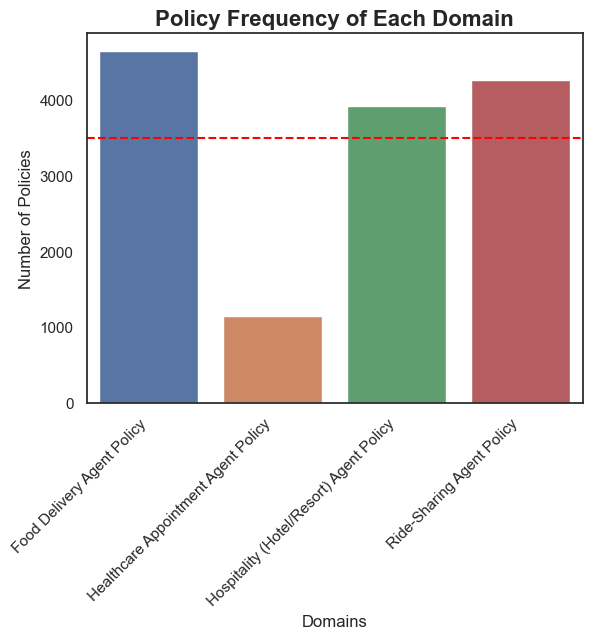

In [418]:
sns.set_theme(style="white")
domain_counts = agent_df["domain"].value_counts()
avg = domain_counts.sum()/len(domain_counts)
ax = sns.countplot(data=agent_df, x="domain", hue="domain")
ax.set_title("Policy Frequency of Each Domain", fontsize=16, fontweight="bold")
ax.set_xlabel("Domains", fontsize=12)
ax.set_ylabel("Number of Policies", fontsize=12)
ax.axhline(y=avg, color="red", linestyle="--", label="threshold")
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

### Interpretation
After observing the average we see it listed around 3500. Healthcare seems to be overwhelmed by the remaining domain categories with Food Delivery being the highest amount overall.  Therefore, we need to keep in mind that healthcare representations might be lacking enough data to represent the domain category correctly.  Fortunately Seaborn provides different visualizations that help display these inadequacies in our dataset.

Text(0, 0.5, 'Total Number of User Messages')

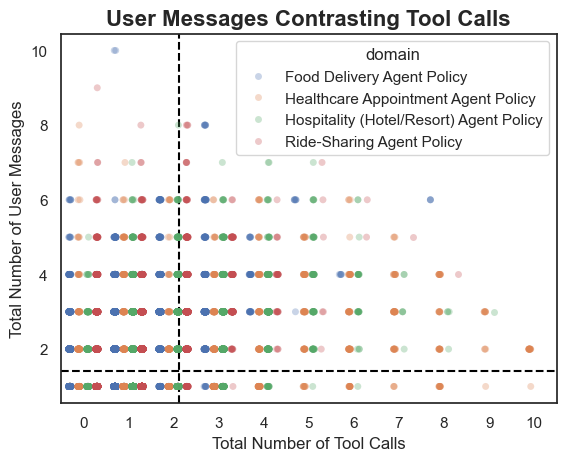

In [419]:
bx = sns.stripplot(data=agent_df, x="num_tool_calls", y="num_user", 
              hue="domain", dodge=True, alpha=0.3, jitter=True)
user_messages_avg = agent_df["num_user"].mean()
tool_calls_avg = agent_df["num_tool"].mean()
bx.axhline(y=tool_calls_avg, color="black", linestyle="--", label="threshold")
bx.axvline(x=user_messages_avg, color="black", linestyle="--", label="threshold")
bx.set_title("User Messages Contrasting Tool Calls", fontsize=16, fontweight="bold")
bx.set_xlabel("Total Number of Tool Calls", fontsize=12)
bx.set_ylabel("Total Number of User Messages", fontsize=12)

### Interpretation
Due to the discrete nature of what we are looking at, most of this data will be compressed (thousands of units all in one section of the graph).  However, using a stripplot we can see that the range of 4 users crossectioned by 2 tool calls carries a strong majority of all 4 categories.  When viewing the healthcare appointment hues it seems they struggle from excessive tool call, strongly correlated with hospitality policies compared to food delivery and ride-sharing.  Food delivery tends to have a higher count of user messages and carries some of the largest outlier data points (10 x 1, 8 x 3, 6 x 8).  Therefore, I would interpret this as food service being less efficient when it comes to escalations and possible issues in their customer service.  Ride-sharing seems to be the most efficient agent policy producing few visual outliers and having a tight grouping for lower number of user messages and number of overall tools called.

[Text(0.5, 0, 'Food Delivery Agent Policy'),
 Text(1.5, 0, 'Healthcare Appointment Agent Policy'),
 Text(2.5, 0, 'Hospitality (Hotel/Resort) Agent Policy'),
 Text(3.5, 0, 'Ride-Sharing Agent Policy')]

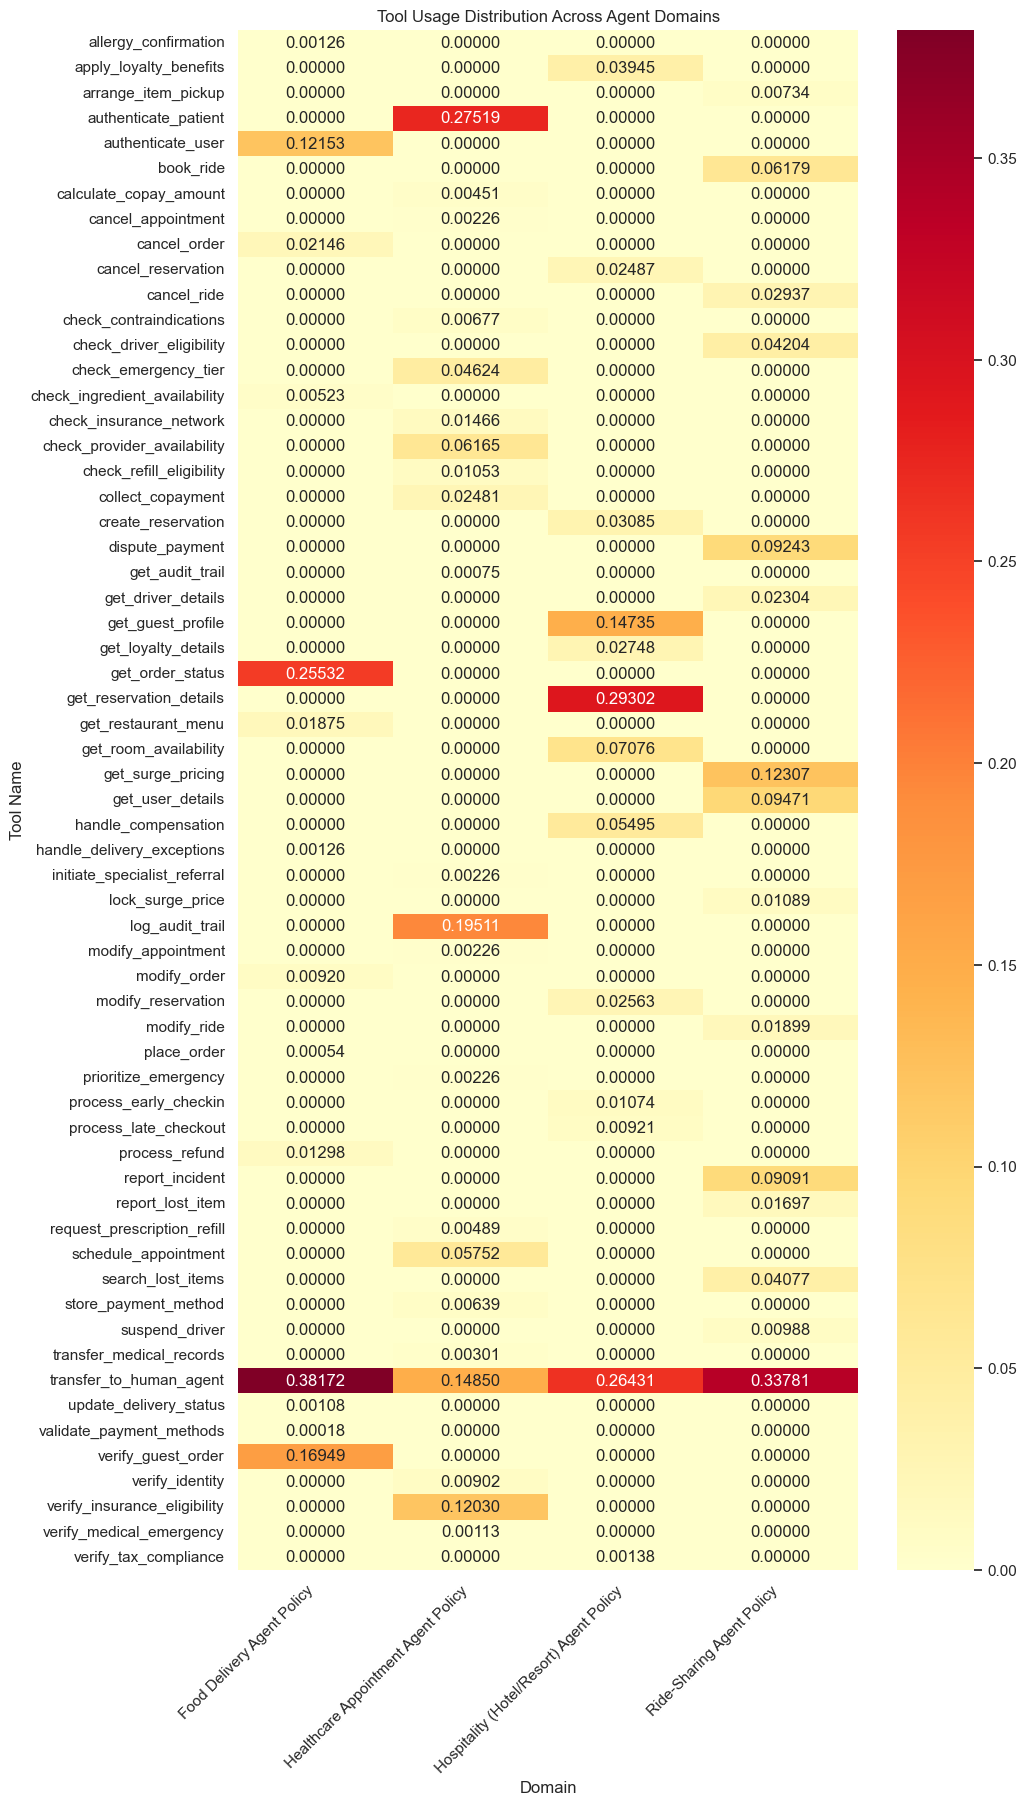

In [436]:
tool_matrix = normalize_tool_name(agent_df)
plt.subplots(figsize=(10, 20))
cx = sns.heatmap(tool_matrix, annot=True, fmt=".5f", cmap="YlOrRd")
cx.set_title("Tool Usage Distribution Across Agent Domains")
cx.set_xlabel("Domain")
cx.set_ylabel("Tool Name")
cx.set_xticklabels(cx.get_xticklabels(), rotation=45, ha="right")

### Interpretation
When looking at the overall tool calls we can say the majority of them are low frequency or non-existent possibly because of the tool not existing in that domain.  However, we normalized the human-in-the-loop call so we can view the epitome of most tool calls since an agent's responsibility is most likely to terminate the task with a human.  The next category that sticks out is status checking of orders or service.

## Summary

### Data Bias
Bias can enter when parsing the agent's policy since some domains contain substeps that don't conform.

#### i.e. Healthcare
```
*Appointment Types*:  
1. **Emergency**: Requires immediate care (tier 1-3)  
2. **Urgent**: Within 24 hours  
3. **Routine**: 7+ day window  
4. **Follow-up**: Linked to previous visit  
```
#### i.e. Healthcare
```
**Cancellation Policy**  
| Time Before Appointment | Fee |  
|-------------------------|-----|  
| <24 hours | $50 |  
| <1 hour | $100 + copay |  
*Exceptions: Medical emergencies (requires MD note)*  
```

### Outcomes
We can see that Healthcare tends to include a Cancellation Policy, which is technically counted correctly right now; however, this data could be counted in different ways, which could explain certain things as: higher tool calling, observed inefficiencies, and healthcare having a more difficult escalation path.  If we trained agents on some of the statistics from this dataset, then healthcare would be lacking the sufficient parsing to provide sufficient datapoints.  Looking back to our "Policy Frequency of Each Domain" healthcare is highly underrepresented and would need some sort of sampling and balancing if used for formal training.
